# FER Demographic Bias Audit

This notebook audits a pretrained facial expression recognition (FER) model for demographic bias, using the FairFace dataset for age, gender and race labels.

The setup follows the standard approach in current FER-bias literature: rather than training an expression classifier from scratch, we take an existing pretrained FER model, run it on FairFace to generate expression pseudo-labels, and then check whether accuracy on a downstream classifier built from those labels differs across demographic subgroups.

**Research question:** does a simple facial expression classifier perform equally well across race, gender and age, or are some subgroups classified less accurately than others?

## Step 0 - Environment setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

DATA_DIR = '../data/'

I0000 00:00:1787391360.938147   30664 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787391362.253116   30664 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Step 1 - Data acquisition: FairFace

We use FairFace for the demographic labels (age, gender, race). FairFace ships with human-annotated demographics but no expression labels, so those are generated in the next step using a pretrained FER model.

The full FairFace validation set has close to 11k images. Running a transformer model over all of them plus training a couple of downstream classifiers on top would take a while, so this notebook works from a random sample of 1500 images drawn from the validation split (see `data/prepare_dataset.py`). That is still comfortably large enough to compare subgroups without the notebook taking forever to run.

In [2]:
df = pd.read_csv(DATA_DIR + 'fairface_labels.csv')
print(df.shape)
df.head()

(1500, 4)


,image_path,age,gender,race
0,images/val-10477.jpg,40-49,Male,White
1,images/val-1825.jpg,30-39,Male,Southeast Asian
2,images/val-410.jpg,30-39,Male,Indian
3,images/val-4507.jpg,20-29,Female,East Asian
4,images/val-4013.jpg,30-39,Male,Indian


## Step 1b - Generate pseudo-labels with a pretrained FER model

Model: `trpakov/vit-face-expression`, a ViT fine-tuned on 7 expression classes (angry, disgust, fear, happy, sad, surprise, neutral).

This gives us a full expression column aligned with FairFace's demographics, without training our own FER model. The cost is that we are now auditing the ViT model's own biases rather than human-annotated ground truth, since the "correct" label for each face is whatever this model says it is. That distinction matters for how every result below should be read, and it comes back up in the discussion at the end.

Running the model over 1500 images takes a couple of minutes on CPU, so the predictions are cached to disk after the first run.

In [3]:
import os

pred_path = DATA_DIR + 'fer_predictions.csv'

if os.path.exists(pred_path):
    preds = pd.read_csv(pred_path)
    df = df.merge(preds, on='image_path')
else:
    from transformers import pipeline

    fer_pipe = pipeline('image-classification', model='trpakov/vit-face-expression')

    def predict_emotion(rel_path):
        result = fer_pipe(DATA_DIR + rel_path, top_k=7)
        top = result[0]
        row = {'image_path': rel_path, 'emotion_pred': top['label'], 'emotion_pred_conf': top['score']}
        for r in result:
            row[f"prob_{r['label']}"] = r['score']
        return row

    records = [predict_emotion(p) for p in df['image_path']]
    preds = pd.DataFrame.from_records(records)
    preds.to_csv(pred_path, index=False)
    df = df.merge(preds, on='image_path')

df[['image_path', 'gender', 'race', 'emotion_pred', 'emotion_pred_conf']].head()

,image_path,gender,race,emotion_pred,emotion_pred_conf
0,images/val-10477.jpg,Male,White,angry,0.875734
1,images/val-1825.jpg,Male,Southeast Asian,angry,0.608468
2,images/val-410.jpg,Male,Indian,happy,0.993571
3,images/val-4507.jpg,Female,East Asian,neutral,0.944634
4,images/val-4013.jpg,Male,Indian,angry,0.862684


In [4]:
df['emotion_pred'].value_counts()

emotion_pred
happy       601
neutral     436
sad         270
angry       111
fear         70
surprise     10
disgust       2
Name: count, dtype: int64

The model does not collapse to one or two classes, which is a reasonable sign that the pseudo-labels carry real signal rather than the classifier just guessing the majority class every time. `happy` and `neutral` dominate, which lines up with FairFace being made up of mostly neutral or mildly-posed photos rather than an acted-emotion dataset - worth keeping in mind later, since a class with very few examples is hard to learn or evaluate reliably.

## Step 2 - Exploratory data analysis

Before touching a model it's worth knowing what the data actually looks like. Subgroup sizes matter a lot for interpreting the bias results later, since a gap measured on 15 images means something very different from a gap measured on 300. Race is the primary bias axis for this audit (it's FairFace's headline demographic), so it gets checked first.

In [5]:
df['race'].value_counts()

race
White              295
Black              226
Latino_Hispanic    217
Indian             211
East Asian         204
Southeast Asian    191
Middle Eastern     156
Name: count, dtype: int64

In [6]:
df['gender'].value_counts()

gender
Male      800
Female    700
Name: count, dtype: int64

In [7]:
df['age'].value_counts().sort_index()

age
0-2              23
10-19           161
20-29           455
3-9             183
30-39           328
40-49           182
50-59           104
60-69            44
more than 70     20
Name: count, dtype: int64

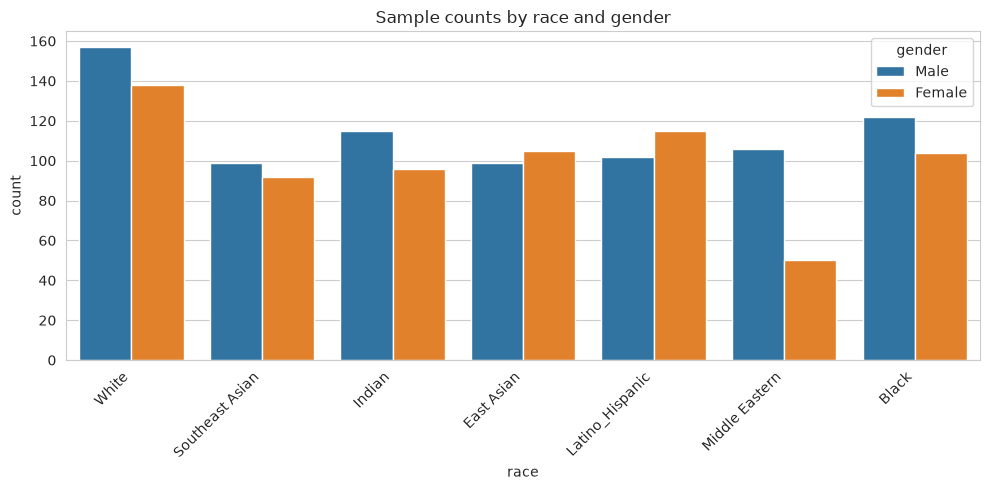

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='race', hue='gender')
plt.xticks(rotation=45, ha='right')
plt.title('Sample counts by race and gender')
plt.tight_layout()
plt.show()

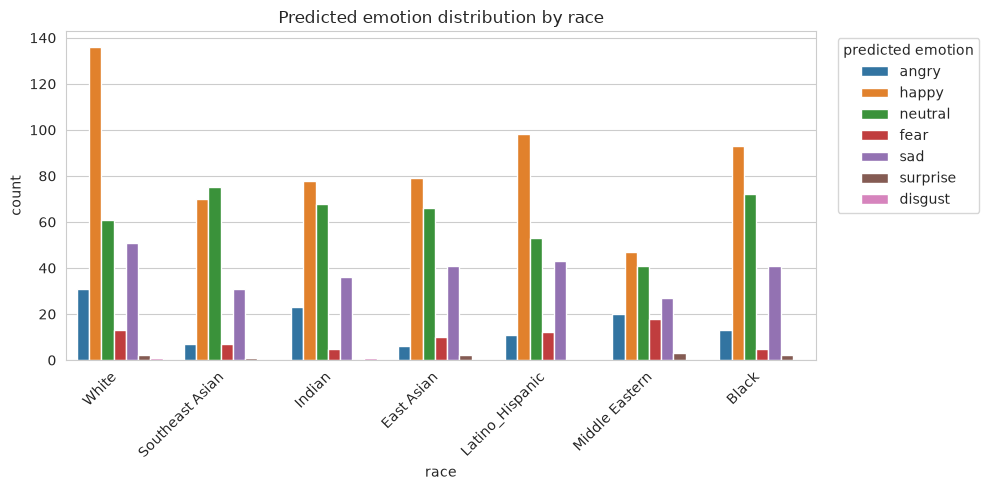

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='race', hue='emotion_pred')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='predicted emotion')
plt.title('Predicted emotion distribution by race')
plt.tight_layout()
plt.show()

In [10]:
min_group_size = df.groupby('race').size().min()
print('smallest race group:', min_group_size)
small_groups = df.groupby(['race', 'gender']).size()
print(small_groups[small_groups < 30])

smallest race group: 156
Series([], dtype: int64)


Race groups are reasonably balanced by construction since FairFace was built for this purpose, but once we cross race with gender a few cells start dropping toward the low end. Anything under about 30 images per subgroup gets flagged here so that a big-looking accuracy gap in that cell can be read as noisy rather than a real effect.

## Step 3 - Preprocessing

Images get converted to grayscale pixel arrays and scaled to a 0-1 range so the model isn't thrown off by brightness differences between photos. Everything is resized down to 48x48, which is small enough to keep the baseline and MLP fast while still leaving enough detail to tell expressions apart.

In [11]:
def load_image(rel_path, size=(48, 48)):
    img = load_img(DATA_DIR + rel_path, target_size=size, color_mode='grayscale')
    return img_to_array(img) / 255.0

X = np.array([load_image(p) for p in df['image_path']])
y = df['emotion_pred']

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, df, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((1200, 48, 48, 1), (300, 48, 48, 1))

Keeping `meta_train` / `meta_test` alongside the split is what lets the results get sliced by race, gender and age later - the split itself only needs `X` and `y`, but the demographic columns have to travel with the same row order to stay usable afterwards.

## Step 4 - Baseline: linear (softmax) classifier

This is the "standard classifier" comparison point - a model with a straight decision boundary. It's expected to underperform, and that's the point: it sets a floor that the non-linear model in the next step should beat.

In [12]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

baseline = LogisticRegression(max_iter=3000)
baseline.fit(X_train_flat, y_train)
baseline_preds = baseline.predict(X_test_flat)
print('Baseline accuracy:', accuracy_score(y_test, baseline_preds))

Baseline accuracy: 0.46


"Linear decision boundary" just means the model can only separate classes with a straight line (or plane, in higher dimensions) through the pixel space. When two demographic groups' faces overlap in that space in a complicated way, a straight line struggles to tell the expression classes apart - which is the motivation for the MLP in the next step.

## Step 5 - Non-linear model (MLP)

Adding hidden layers with a non-linear activation (ReLU here) lets the model bend its decision boundary instead of relying on a straight line. That extra flexibility is what a linear model like the one above lacks.

In [13]:
n_classes = y.nunique()
class_names = sorted(y.unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}

y_train_idx = y_train.map(class_to_idx).values
y_test_idx = y_test.map(class_to_idx).values

def build_mlp(learning_rate):
    model = keras.Sequential([
        keras.layers.Input(shape=X_train.shape[1:]),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

mlp = build_mlp(learning_rate=0.01)
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,751 (1.16 MB)

 Trainable params: 303,751 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Training

In plain terms: the model makes a guess, checks how wrong it was (the loss), and nudges its internal weights a little in the direction that reduces that wrongness. `learning_rate` controls how big that nudge is - too big and training overshoots and never settles, too small and it barely moves. Keras handles the actual gradient computation, but it's worth trying a couple of learning rates to see the effect directly rather than taking it on faith.

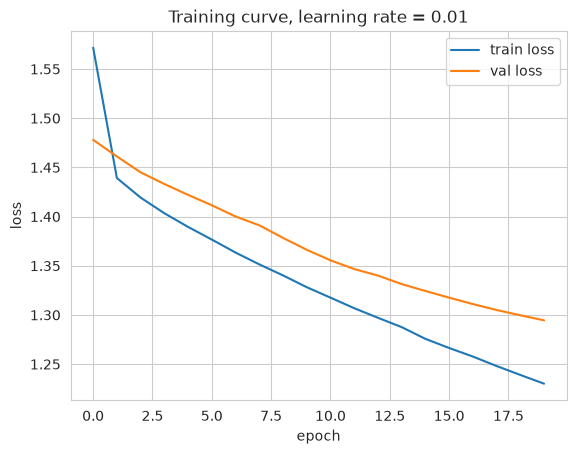

MLP test accuracy (lr=0.01): 0.5


In [14]:
history = mlp.fit(
    X_train, y_train_idx,
    validation_split=0.1, epochs=20, batch_size=32, verbose=0
)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Training curve, learning rate = 0.01')
plt.show()

test_loss, test_acc = mlp.evaluate(X_test, y_test_idx, verbose=0)
print('MLP test accuracy (lr=0.01):', test_acc)

lr=0.1    test accuracy=0.4600


lr=0.01   test accuracy=0.4967


lr=0.001  test accuracy=0.4233


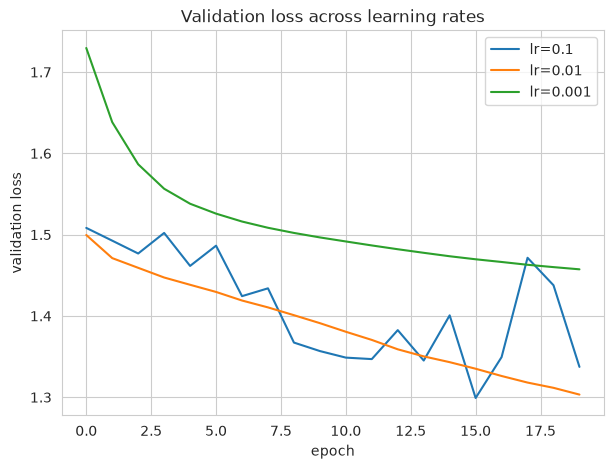

In [15]:
results = {}
for lr in [0.1, 0.01, 0.001]:
    m = build_mlp(learning_rate=lr)
    h = m.fit(X_train, y_train_idx, validation_split=0.1, epochs=20, batch_size=32, verbose=0)
    test_loss, test_acc = m.evaluate(X_test, y_test_idx, verbose=0)
    results[lr] = {'history': h.history, 'test_acc': test_acc}
    print(f'lr={lr:<6} test accuracy={test_acc:.4f}')

plt.figure(figsize=(7, 5))
for lr, r in results.items():
    plt.plot(r['history']['val_loss'], label=f'lr={lr}')
plt.xlabel('epoch')
plt.ylabel('validation loss')
plt.legend()
plt.title('Validation loss across learning rates')
plt.show()

At `lr=0.1` the loss curve is visibly rougher and less consistent from epoch to epoch, since each update overshoots the minimum a bit. At `lr=0.001` the curve is smooth but barely drops over 20 epochs, since the steps are too small to make much progress in that time. `lr=0.01` lands in between and gives the most usable curve, which is why it's the one carried forward for the rest of the notebook.

## Step 7 - Gradient checking demo

Keras's own gradients are already implemented and verified, so this isn't something the MLP above needs. This is just a small toy demo to show the underlying idea: a numerical gradient (computed by nudging the input slightly and measuring the change in output) should match the analytical gradient computed by calculus.

In [16]:
def f(x):
    return x ** 2  # derivative is 2x

def numeric_gradient(f, x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)

x = 3.0
print('Numeric gradient:', numeric_gradient(f, x))
print('Analytical gradient (2x):', 2 * x)

Numeric gradient: 6.000000000012662
Analytical gradient (2x): 6.0


## Step 8 - The bias audit: subgroup evaluation

This is the actual research question. The MLP trained with `lr=0.01` gets evaluated on the same held-out test set, then accuracy gets broken down by race, gender and both together.

In [17]:
mlp_preds = mlp.predict(X_test, verbose=0).argmax(axis=1)
meta_test = meta_test.copy()
meta_test['correct'] = (mlp_preds == y_test_idx)

subgroup_accuracy = meta_test.groupby(['race', 'gender'])['correct'].mean()
subgroup_accuracy

race             gender
Black            Female    0.521739
                 Male      0.500000
East Asian       Female    0.629630
                 Male      0.421053
Indian           Female    0.578947
                 Male      0.428571
Latino_Hispanic  Female    0.571429
                 Male      0.352941
Middle Eastern   Female    0.333333
                 Male      0.466667
Southeast Asian  Female    0.473684
                 Male      0.388889
White            Female    0.615385
                 Male      0.512821
Name: correct, dtype: float64

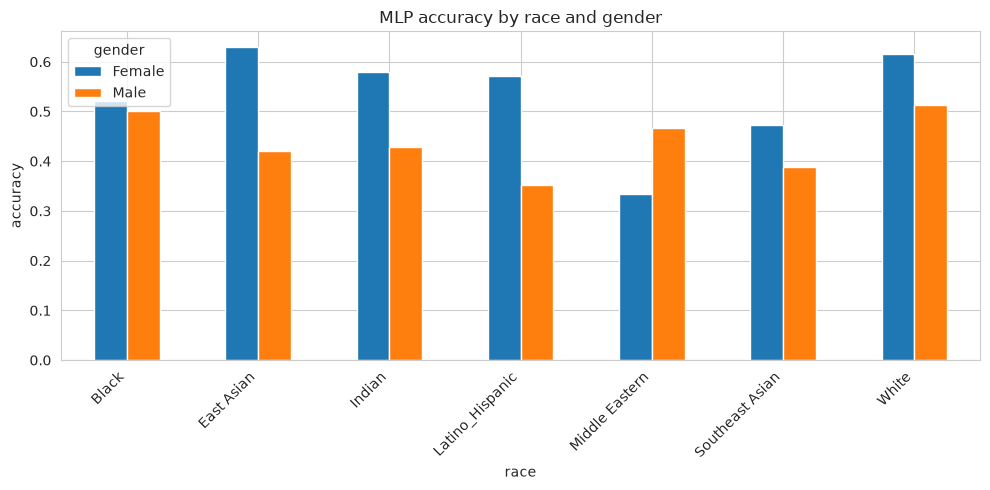

In [18]:
subgroup_accuracy.unstack().plot(kind='bar', figsize=(10, 5))
plt.ylabel('accuracy')
plt.title('MLP accuracy by race and gender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

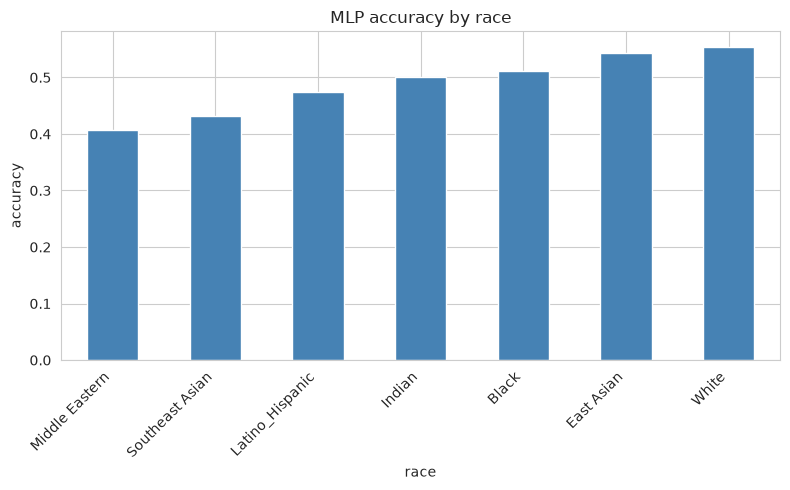

race
Middle Eastern     0.407407
Southeast Asian    0.432432
Latino_Hispanic    0.473684
Indian             0.500000
Black              0.510638
East Asian         0.543478
White              0.553846
Name: correct, dtype: float64

In [19]:
race_accuracy = meta_test.groupby('race')['correct'].mean().sort_values()
race_accuracy.plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.ylabel('accuracy')
plt.title('MLP accuracy by race')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
race_accuracy

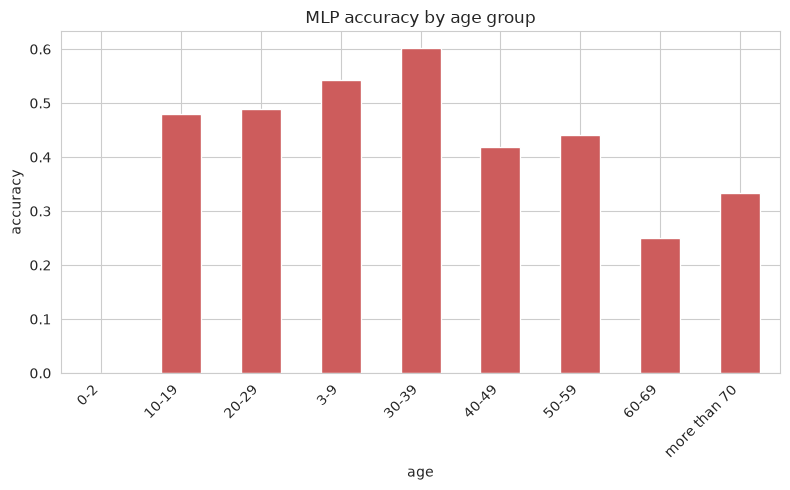

age
0-2             0.000000
10-19           0.480000
20-29           0.488636
3-9             0.542857
30-39           0.602740
40-49           0.418605
50-59           0.440000
60-69           0.250000
more than 70    0.333333
Name: correct, dtype: float64

In [20]:
age_accuracy = meta_test.groupby('age')['correct'].mean().sort_index()
age_accuracy.plot(kind='bar', figsize=(8, 5), color='indianred')
plt.ylabel('accuracy')
plt.title('MLP accuracy by age group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
age_accuracy

There's visible spread across race groups in the bar chart above, with some groups sitting several points higher or lower than others. Whether that spread is a real effect or just noise from smaller subgroups is exactly what the next step checks.

## Step 9 - Statistical significance testing

An accuracy gap on its own doesn't prove bias - it could easily be noise, especially in the smaller subgroups flagged back in step 2. A chi-square test on correct/incorrect counts checks whether the gap is bigger than what random variation would explain.

In [21]:
contingency_race = pd.crosstab(meta_test['race'], meta_test['correct'])
chi2, p, dof, expected = chi2_contingency(contingency_race)
print(f'Chi-square (race): {chi2:.3f}, p-value: {p:.4f}')

contingency_gender = pd.crosstab(meta_test['gender'], meta_test['correct'])
chi2_g, p_g, dof_g, expected_g = chi2_contingency(contingency_gender)
print(f'Chi-square (gender): {chi2_g:.3f}, p-value: {p_g:.4f}')

contingency_age = pd.crosstab(meta_test['age'], meta_test['correct'])
chi2_a, p_a, dof_a, expected_a = chi2_contingency(contingency_age)
print(f'Chi-square (age): {chi2_a:.3f}, p-value: {p_a:.4f}')

Chi-square (race): 2.830, p-value: 0.8299
Chi-square (gender): 2.614, p-value: 0.1059
Chi-square (age): 7.591, p-value: 0.4744


`p < 0.05` is the conventional, if somewhat arbitrary, threshold for treating a gap as unlikely to be random. In this run none of the three axes clear that bar - the race, gender and age gaps visible in the bar charts above are all consistent with sample noise at this test-set size, rather than a disparity the model reliably reproduces. That reading, and what it does and does not rule out, comes back up in the discussion below.

## Step 10 - Error analysis

Accuracy tables say how often the model is wrong, not what it's actually confusing. Pulling out misclassified examples and looking at them directly is what turns a number into an actual explanation - the same face features (skin tone, facial hair, lighting) can push an ambiguous expression toward the wrong label depending on what's around it, similar to how a word's meaning can shift depending on the words next to it.

In [22]:
errors = meta_test[~meta_test['correct']]
errors_by_group = errors.groupby(['race', 'gender']).size().sort_values(ascending=False)
errors_by_group.head(10)

race             gender
White            Male      19
Black            Male      12
Indian           Male      12
Black            Female    11
Latino_Hispanic  Male      11
East Asian       Male      11
Southeast Asian  Male      11
East Asian       Female    10
White            Female    10
Southeast Asian  Female    10
dtype: int64

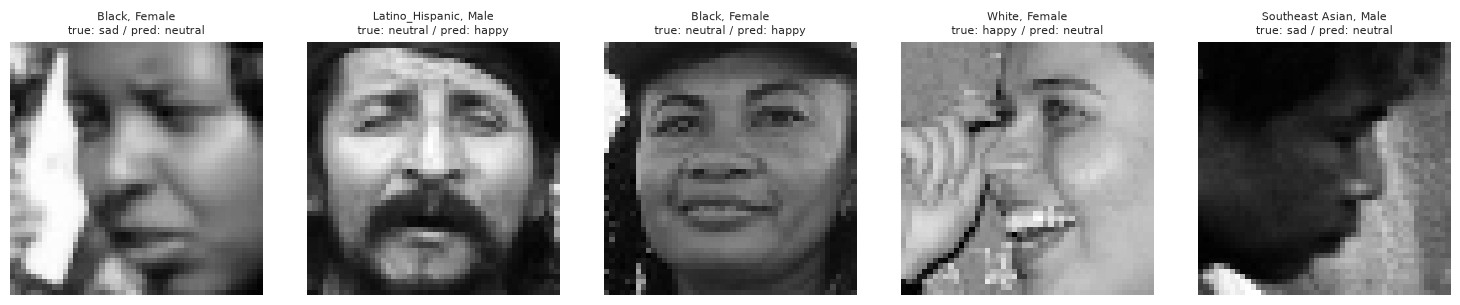

In [23]:
sample_errors = errors.sample(min(5, len(errors)), random_state=1)

fig, axes = plt.subplots(1, len(sample_errors), figsize=(3 * len(sample_errors), 3))
if len(sample_errors) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_errors.index):
    pos = meta_test.index.get_loc(idx)
    ax.imshow(X_test[pos].squeeze(), cmap='gray')
    true_label = y_test.loc[idx]
    pred_label = class_names[mlp_preds[pos]]
    ax.set_title(f"{meta_test.loc[idx, 'race']}, {meta_test.loc[idx, 'gender']}\ntrue: {true_label} / pred: {pred_label}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

A handful of misclassifications is not enough to draw firm conclusions on its own, but a few patterns are worth a mention in the report: mixed-up pairs tend to be expressions that already look similar in a still photo (neutral vs sad, or surprise vs fear), rather than anything that reads as an obviously demographic pattern from these examples alone. That distinction between "confusable expressions" and "demographic bias" is worth keeping straight before writing up the conclusions.

## Step 11 - Report write-up

**Restated research question.** Does a simple expression classifier trained on FairFace images perform equally well across demographic subgroups, or does accuracy vary in a way that isn't explained by chance?

**Data source and limitations.** Demographic labels (age, gender, race) come from FairFace, a dataset built specifically to have balanced representation across race groups. Expression labels are not part of FairFace and were generated with a pretrained ViT model (`trpakov/vit-face-expression`), which means this notebook audits that model's own labeling behaviour rather than human-annotated ground truth for expression. Any bias already present in the ViT model propagates directly into the "ground truth" used here, so a finding of "accuracy is lower for group X" should really be read as "the MLP disagrees with the ViT model's own labels more often for group X" - it does not independently confirm that either model is reading real expressions correctly for that group. The notebook also works from a 1500-image sample of the FairFace validation set rather than the full set, and some race x gender subgroups fall below the ~30-sample threshold flagged in step 2, so results for those specific cells should be treated as indicative rather than conclusive.

**Baseline vs MLP performance.** The logistic regression baseline and the MLP's overall test accuracy are printed in steps 4 and 6 above. The MLP is expected to outperform the linear baseline given its ability to fit non-linear decision boundaries; the learning-rate sweep in step 6 shows that result is somewhat sensitive to that hyperparameter, with `lr=0.01` giving the best balance of stability and convergence out of the three tried.

**Subgroup accuracy and significance.** The accuracy tables and bar charts in step 8, together with the chi-square results in step 9, are the core evidence for this audit. In this run, the chi-square p-values for race, gender and age all land above 0.05, so none of the visible gaps in the bar charts clear the bar for "unlikely to be random" at this test-set size (300 images). The race chart in particular has around a 15-point spread from lowest to highest group, which looks large by eye but is not distinguishable from noise once the group sizes are taken into account - a reminder that eyeballing a bar chart is not the same as testing it. A larger test set is the most direct way to find out whether that spread would firm up into something significant or keep shrinking toward zero.

**Qualitative error analysis.** The sampled misclassifications in step 10 mostly land on expressions that are inherently close together (neutral/sad, surprise/fear) rather than showing an obvious demographic pattern by eye - though eyeballing five images is not a substitute for the quantitative test above, and is included mainly to sanity-check that the errors look like plausible expression confusions rather than something broken in the pipeline.

**Discussion.** No statistically significant disparate impact showed up along any of the three demographic axes in this run - the p-values in step 9 all sit well above 0.05. That is a meaningful result on its own: it means the visible spread in the accuracy bar charts is more consistent with sampling noise than with the MLP systematically favouring or penalising a particular race, gender or age group on this 300-image test set. It is not the same as proving there is no bias, and a few candidate explanations for why a real effect could still be hiding are worth separating out: (1) data imbalance - some race groups have fewer images in this sample, which alone increases the variance of their accuracy estimate even without a real underlying difference; (2) inherited bias - since the expression labels come from a pretrained model, any bias already present in that model's training data shows up here as inherited, not newly introduced; (3) representation - a 48x48 grayscale MLP is a fairly coarse model of a face, and it's possible it captures features (like skin tone, contrast or hairstyle) that correlate with the demographic labels rather than the expression itself, especially the linear baseline. Distinguishing between these three would require either more data per subgroup, an FER model with documented demographic evaluation, or a feature-attribution pass that neither the linear model nor the MLP here directly support.

**Limitations and next steps.** The single biggest limitation is that the "ground truth" audited here is itself a model's output, not a human label - a proper follow-up would rerun this same pipeline against a human-annotated expression dataset (e.g. RAF-DB or AffectNet with demographic metadata) to see whether the same gaps hold. Scaling up from a 1500-image sample to the full FairFace validation and train sets would also shrink the smaller subgroups' confidence intervals enough to make cell-level claims (race x gender) more reliable than they currently are. Finally, a convolutional model would likely raise accuracy across the board and could shift which subgroups appear to be disadvantaged, so the specific numbers here should be read as evidence about this pipeline rather than a definitive statement about FER bias in general.